# Três arboviroses, um mosquito: dengue, chikungunya e zika

**A pergunta:** o *Aedes aegypti* transmite três vírus diferentes no Brasil. Eles
circulam juntos, são notificados no mesmo sistema e costumam ser tratados como
um bloco só — mas atingem pessoas diferentes, em épocas diferentes, com
gravidades diferentes. Este notebook separa os três e mostra em que exatamente
eles divergem.

**Fonte:** Sistema de Informação de Agravos de Notificação (SINAN/DATASUS),
com denominadores do IBGE.

**Tempo estimado:** 8 a 15 minutos — os arquivos são grandes.

**O que você leva daqui:** o método para analisar milhões de notificações sem
travar o computador, a definição oficial de caso provável, e o perfil comparado
das três doenças em sazonalidade, idade, sexo e gravidade.

In [2]:
%pip install pysus nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


## 1. O que você pode trocar

In [4]:
ANO = 2024        # ano de notificação
DOENCAS = {"DENG": "Dengue", "CHIK": "Chikungunya", "ZIKA": "Zika"}

UFS = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF",
}
print(f"Ano: {ANO} — doenças: {', '.join(DOENCAS.values())}")

Ano: 2024 — doenças: Dengue, Chikungunya, Zika


## 2. A base que não cabe na memória

O SINAN é **nacional** — não aceita filtro por estado no download — e a dengue
de um ano epidêmico tem milhões de linhas e mais de cem colunas. Carregar isso
com `as_dataframe=True` encerra o Python por falta de memória, e todo o
trabalho da sessão se perde.

A saída é não carregar. Pedimos o **caminho do arquivo** e deixamos o duckdb ler
direto do disco, trazendo só o resumo. É a diferença entre precisar de dezenas
de gigabytes e precisar de alguns megabytes.

In [5]:
from pysus import sinan

arquivos = {}
for sigla, nome in DOENCAS.items():
    caminhos = sinan(disease=sigla, year=ANO)     # sem as_dataframe: só o caminho
    if not caminhos:
        print(f"{nome}: sem arquivo publicado para {ANO}")
        continue
    arquivos[sigla] = caminhos[0].replace("\\", "/")

print(f"{'Doença':<14} {'Arquivo':<20} {'Tamanho':>10} {'Linhas':>12} {'Colunas':>8}")
for sigla, caminho in arquivos.items():
    tamanho = os.path.getsize(caminho) / 1024 / 1024
    linhas = con.execute(f"SELECT count(*) FROM read_parquet('{caminho}')").fetchone()[0]
    colunas = len(con.execute(
        f"DESCRIBE SELECT * FROM read_parquet('{caminho}')").df())
    print(f"{DOENCAS[sigla]:<14} {os.path.basename(caminho):<20} "
          f"{tamanho:>8.0f} MB {mil(linhas):>12} {colunas:>8}")

Doença         Arquivo                 Tamanho       Linhas  Colunas
Dengue         DENGBR24.parquet          144 MB    6.564.924      121
Chikungunya    CHIKBR24.parquet            9 MB      426.214      122
Zika           ZIKABR24.parquet            1 MB       43.312       38


In [6]:
maior = max(arquivos.values(), key=os.path.getsize)
linhas = con.execute(f"SELECT count(*) FROM read_parquet('{maior}')").fetchone()[0]
colunas = len(con.execute(f"DESCRIBE SELECT * FROM read_parquet('{maior}')").df())

print(f"O maior arquivo tem {mil(linhas)} linhas e {colunas} colunas.")
print(f"No disco, comprimido: {os.path.getsize(maior) / 1024 / 1024:.0f} MB")
print(f"Na memória, se carregado inteiro: perto de "
      f"{linhas * colunas * 40 / 1024**3:.0f} GB")
print()
print("O Colab gratuito oferece cerca de 12 GB. É por isso que o caminho aqui")
print("é sempre o mesmo: consultar o arquivo, nunca carregá-lo.")

O maior arquivo tem 6.564.924 linhas e 121 colunas.
No disco, comprimido: 144 MB
Na memória, se carregado inteiro: perto de 30 GB

O Colab gratuito oferece cerca de 12 GB. É por isso que o caminho aqui
é sempre o mesmo: consultar o arquivo, nunca carregá-lo.


## 3. Cada doença tem sua própria ficha

Antes de escrever qualquer consulta, uma descoberta que economiza tempo: os
arquivos do SINAN **não têm as mesmas colunas**. A ficha da dengue pergunta se
houve internação; a da chikungunya, não. Além disso, as datas vêm gravadas como
**texto**, e não como data — usá-las direto em função de data dá erro.

Por isso o notebook pergunta ao arquivo quais colunas existem antes de montar
a consulta, e converte as datas com `TRY_CAST`, que devolve vazio em vez de
quebrar quando encontra um valor estranho.

In [7]:
def colunas_de(caminho):
    "Conjunto de colunas existentes no arquivo."
    return set(con.execute(
        f"DESCRIBE SELECT * FROM read_parquet('{caminho}')").df()["column_name"])

campos = {sigla: colunas_de(caminho) for sigla, caminho in arquivos.items()}

comuns = set.intersection(*campos.values())
print(f"Colunas presentes em todas as três: {len(comuns)}")
print()
for campo in ["CLASSI_FIN", "EVOLUCAO", "HOSPITALIZ", "NU_IDADE_N", "CS_SEXO",
              "DT_SIN_PRI", "SG_UF_NOT", "CS_GESTANT", "SOROTIPO"]:
    onde = [DOENCAS[s] for s in arquivos if campo in campos[s]]
    print(f"  {campo:<12} {', '.join(onde) if onde else 'em nenhuma'}")

Colunas presentes em todas as três: 36

  CLASSI_FIN   Dengue, Chikungunya, Zika
  EVOLUCAO     Dengue, Chikungunya, Zika
  HOSPITALIZ   Dengue, Chikungunya
  NU_IDADE_N   Dengue, Chikungunya, Zika
  CS_SEXO      Dengue, Chikungunya, Zika
  DT_SIN_PRI   Dengue, Chikungunya, Zika
  SG_UF_NOT    Dengue, Chikungunya, Zika
  CS_GESTANT   Dengue, Chikungunya, Zika
  SOROTIPO     Dengue, Chikungunya


### Caso provável: a definição que o Ministério da Saúde publica

Nem toda notificação é um caso. Parte é descartada depois da investigação. O
número que aparece nos boletins epidemiológicos é o de **casos prováveis**:
notificações **menos** as descartadas, pelo campo `CLASSI_FIN`.

Aqui mora a armadilha que quase estragou este notebook. **O código do descarte
não é o mesmo nas três doenças.** Na dengue é o 8; na chikungunya é o 5; no
zika é o 2. Aplicar um código só nas três produz números plausíveis e errados
— na chikungunya, nenhuma notificação seria descartada, e o total inflaria em
mais de 60%.

Como descobrir isso sem a tabela oficial em mãos? Olhando para onde estão os
óbitos. O código de descarte é aquele em que praticamente ninguém morre.

In [8]:
for sigla, caminho in arquivos.items():
    tabela = con.execute(f"""
        SELECT COALESCE(CLASSI_FIN, '(vazio)') AS codigo,
               count(*) AS casos,
               sum(CASE WHEN EVOLUCAO = '2' THEN 1 ELSE 0 END) AS obitos
        FROM read_parquet('{caminho}')
        GROUP BY 1 ORDER BY 2 DESC
    """).df()
    tabela["óbitos por 100 mil"] = (
        tabela["obitos"] / tabela["casos"] * 100_000).round(0)
    print(f"\n{DOENCAS[sigla]} — campo CLASSI_FIN")
    print(tabela.to_string(index=False))


Dengue — campo CLASSI_FIN
 codigo   casos  obitos  óbitos por 100 mil
     10 5904136  1532.0                26.0
      8  542641     3.0                 1.0
     11  101392   975.0               962.0
     12    8831  3827.0             43336.0
(vazio)    7924     0.0                 0.0

Chikungunya — campo CLASSI_FIN
 codigo  casos  obitos  óbitos por 100 mil
     13 232047   246.0               106.0
      5 162176     1.0                 1.0
(vazio)  31991     0.0                 0.0

Zika — campo CLASSI_FIN
 codigo  casos  obitos  óbitos por 100 mil
      2  38198     0.0                 0.0
      8   2509     0.0                 0.0
      1   2068     0.0                 0.0
(vazio)    537     0.0                 0.0


A leitura é direta. Na dengue, os códigos 10, 11 e 12 concentram todos os
óbitos e o **8** não tem praticamente nenhum: é o descarte. Na chikungunya, o
13 tem os óbitos e o **5** tem um único: é o descarte. No zika ninguém morreu,
então esse sinal não serve — mas o código **2** reúne 88% das notificações, e
quase todas passaram por exame laboratorial, o padrão de quem foi investigado e
descartado. Faz sentido: num ano de epidemia de dengue, a maioria das suspeitas
de zika volta do laboratório como dengue.

In [9]:
# Código de descarte de cada agravo, identificado acima.
DESCARTE = {"DENG": ["8"], "CHIK": ["5"], "ZIKA": ["2", "8"]}

def resumo_doenca(sigla):
    "Notificações, descartadas, prováveis, óbitos e (se houver) internações."
    caminho = arquivos[sigla]
    tem = campos[sigla]
    codigos = ", ".join(f"'{c}'" for c in DESCARTE[sigla])
    internacao = ("sum(CASE WHEN HOSPITALIZ = '1' THEN 1 ELSE 0 END)"
                  if "HOSPITALIZ" in tem else "NULL")
    return con.execute(f"""
        SELECT count(*) AS notificacoes,
               sum(CASE WHEN CLASSI_FIN IN ({codigos}) THEN 1 ELSE 0 END) AS descartadas,
               sum(CASE WHEN CLASSI_FIN IS NULL OR CLASSI_FIN NOT IN ({codigos})
                        THEN 1 ELSE 0 END) AS provaveis,
               sum(CASE WHEN EVOLUCAO = '2' THEN 1 ELSE 0 END) AS obitos,
               {internacao} AS internados
        FROM read_parquet('{caminho}')
    """).df().iloc[0]

painel = pd.DataFrame({DOENCAS[s]: resumo_doenca(s) for s in arquivos}).T
# o duckdb devolve inteiros grandes como objeto; converter antes de calcular
painel = painel.apply(pd.to_numeric, errors="coerce")
painel["% descartadas"] = (painel["descartadas"] / painel["notificacoes"] * 100).round(1)
painel["Óbitos por 100 mil casos"] = (
    painel["obitos"] / painel["provaveis"] * 100_000).round(1)
painel[["notificacoes", "descartadas", "provaveis", "obitos"]] = (
    painel[["notificacoes", "descartadas", "provaveis", "obitos"]].astype(int))
def filtro_provavel(sigla):
    "Condição SQL que mantém apenas os casos prováveis daquele agravo."
    codigos = ", ".join(f"'{c}'" for c in DESCARTE[sigla])
    return f"(CLASSI_FIN IS NULL OR CLASSI_FIN NOT IN ({codigos}))"

painel[["notificacoes", "descartadas", "% descartadas", "provaveis",
        "obitos", "Óbitos por 100 mil casos"]]

,notificacoes,descartadas,% descartadas,provaveis,obitos,Óbitos por 100 mil casos
Dengue,6564924,542641,8.3,6022283,6337,105.2
Chikungunya,426214,162176,38.1,264038,247,93.5
Zika,43312,40707,94.0,2605,0,0.0


Três leituras.

A **escala**: a dengue não é apenas a mais comum, está uma ordem de grandeza
acima das outras duas.

A **taxa de descarte**, que é altíssima no zika. Quase toda suspeita de zika
acaba sendo outra coisa — quase sempre a própria dengue, que circulava aos
milhões no mesmo período e produz um quadro clínico parecido.

E a **proporção de óbitos entre os casos prováveis**, que costuma surpreender:
depois de aplicar o código de descarte certo de cada doença, dengue e
chikungunya ficam próximas. A chikungunya não é a "leve" das três — ela mata
pouco em números absolutos porque adoece muito menos gente, não porque seja
inofensiva.

## 4. Sazonalidade: quando cada uma chega

Todas dependem do mesmo mosquito, então todas seguem o calor e a chuva. Mas as
curvas não coincidem exatamente — e o descompasso importa para quem organiza
uma campanha.

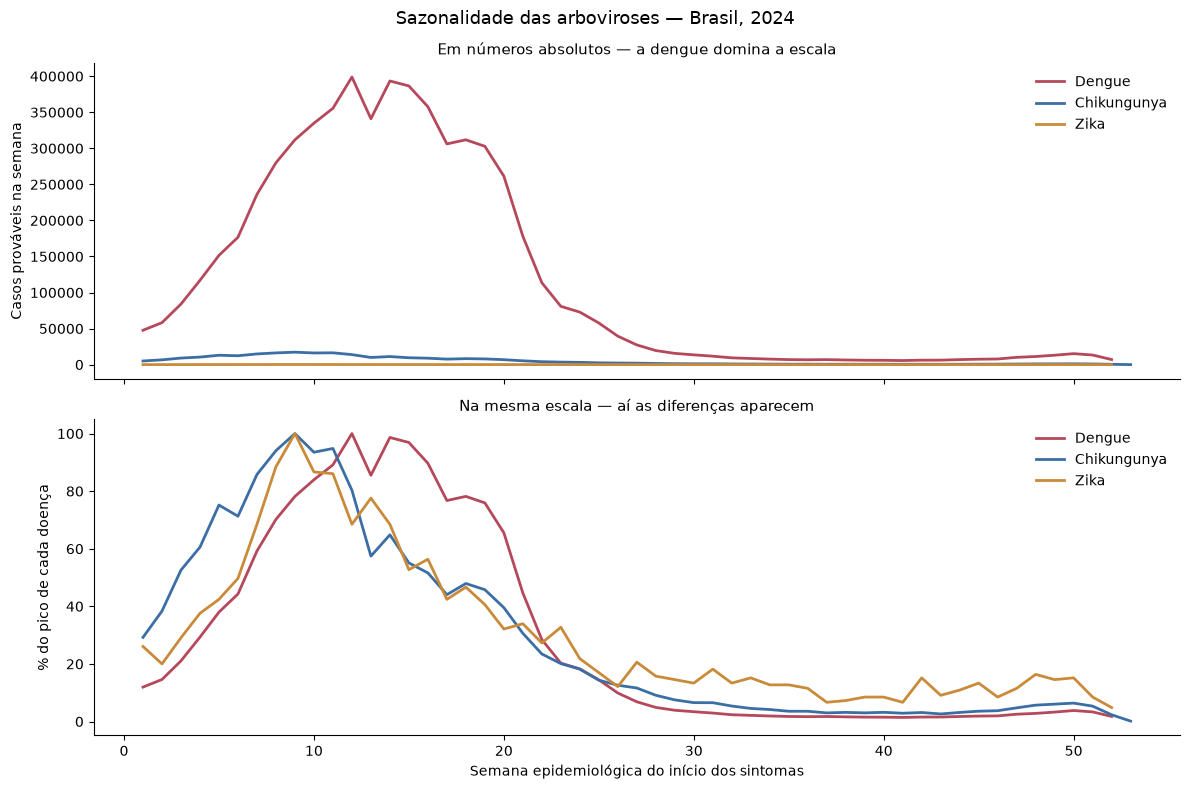

Dengue         pico na semana 12 (398.854 casos na semana)
Chikungunya    pico na semana  9 (17.267 casos na semana)
Zika           pico na semana  9 (165 casos na semana)


In [10]:
def curva_semanal(sigla):
    "Casos prováveis por semana de início dos sintomas."
    return con.execute(f"""
        WITH base AS (
            SELECT TRY_CAST(DT_SIN_PRI AS DATE) AS inicio
            FROM read_parquet('{arquivos[sigla]}')
            WHERE {filtro_provavel(sigla)}
        )
        SELECT CAST(strftime(inicio, '%W') AS INTEGER) AS semana,
               count(*) AS casos
        FROM base
        WHERE inicio IS NOT NULL
          AND CAST(strftime(inicio, '%Y') AS INTEGER) = {ANO}
        GROUP BY 1 ORDER BY 1
    """).df().set_index("semana")["casos"]

curvas = {DOENCAS[s]: curva_semanal(s) for s in arquivos}

figura, (eixo1, eixo2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
cores = {"Dengue": "#b5495b", "Chikungunya": "#3b6ea5", "Zika": "#c98a3a"}

for nome, serie in curvas.items():
    eixo1.plot(serie.index, serie.values, label=nome,
               color=cores.get(nome), linewidth=2)
    relativa = serie / serie.max() * 100
    eixo2.plot(relativa.index, relativa.values, label=nome,
               color=cores.get(nome), linewidth=2)

eixo1.set_ylabel("Casos prováveis na semana")
eixo1.set_title(f"Em números absolutos — a dengue domina a escala", fontsize=11)
eixo1.legend(frameon=False)

eixo2.set_ylabel("% do pico de cada doença")
eixo2.set_xlabel("Semana epidemiológica do início dos sintomas")
eixo2.set_title("Na mesma escala — aí as diferenças aparecem", fontsize=11)
eixo2.legend(frameon=False)

for eixo in (eixo1, eixo2):
    eixo.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Sazonalidade das arboviroses — Brasil, {ANO}", fontsize=13)
plt.tight_layout()
plt.show()

for nome, serie in curvas.items():
    pico = serie.idxmax()
    print(f"{nome:<14} pico na semana {pico:>2} "
          f"({mil(serie.max())} casos na semana)")

## 5. Onde: incidência por 100 mil habitantes

Comparar estados pelo número bruto de casos é comparar tamanhos de população.
O indicador epidemiológico é a **incidência**, e ela muda completamente o mapa:
estados pequenos e quentes aparecem à frente dos gigantes.

In [11]:
from pysus import ibge

caminho_ibge = [c for c in ibge(year=ANO)
                if os.path.basename(c).startswith("PROJ")][0].replace("\\", "/")
populacao = con.execute(f"""
    SELECT CAST(UFCOD AS INTEGER) AS uf, sum(CAST(POPULACAO AS BIGINT)) AS populacao
    FROM read_parquet('{caminho_ibge}') GROUP BY 1
""").df().set_index("uf")["populacao"]
populacao.index = [UFS.get(i, i) for i in populacao.index]

def casos_por_uf(sigla):
    dados = con.execute(f"""
        SELECT TRY_CAST(SG_UF_NOT AS INTEGER) AS uf, count(*) AS casos
        FROM read_parquet('{arquivos[sigla]}')
        WHERE {filtro_provavel(sigla)}
        GROUP BY 1
    """).df().dropna()
    dados["uf"] = [UFS.get(int(u), None) for u in dados["uf"]]
    return dados.dropna(subset=["uf"]).set_index("uf")["casos"]

incidencia = pd.DataFrame({"População": populacao})
for sigla in arquivos:
    casos = casos_por_uf(sigla)
    incidencia[DOENCAS[sigla]] = (casos / populacao * 100_000).round(1)
incidencia = incidencia.dropna(subset=["Dengue"]).sort_values("Dengue", ascending=False)

print("Incidência por 100 mil habitantes\n")
print("Os oito estados com maior incidência de dengue:")
incidencia.head(8)

Incidência por 100 mil habitantes

Os oito estados com maior incidência de dengue:


,População,Dengue,Chikungunya,Zika
DF,2982818.0,6781.1,14.8,0.1
MG,21322691.0,6625.2,781.9,0.3
PR,11824665.0,5280.7,6.8,0.0
SP,45973194.0,4688.0,23.7,0.1
GO,7350483.0,4392.7,148.8,0.8
SC,8058441.0,4028.9,1.8,0.0
ES,4102129.0,3361.0,310.0,2.1
RS,11229915.0,1876.8,3.0,0.0


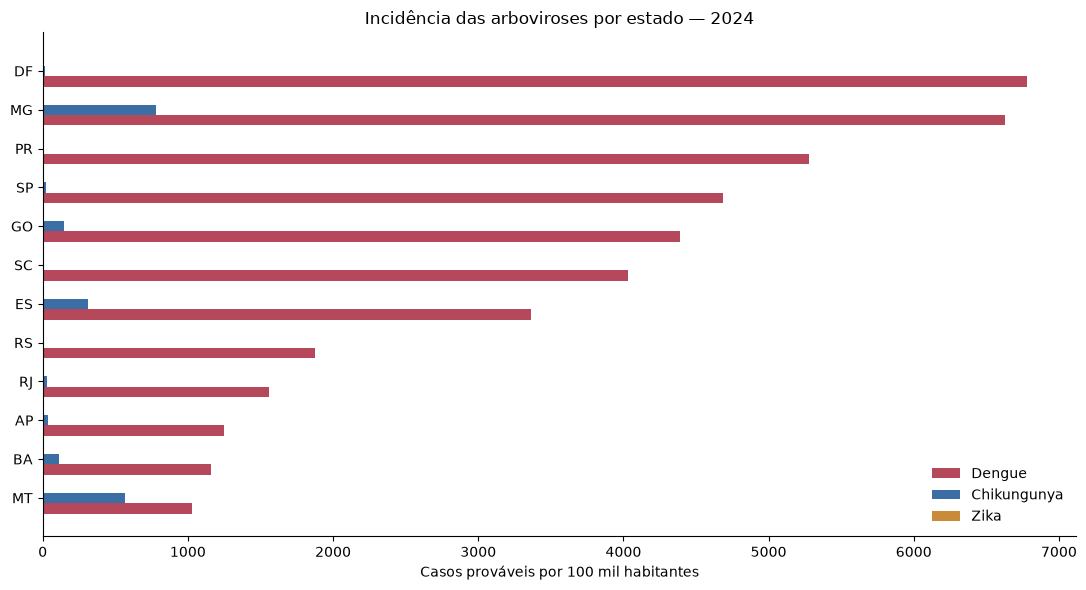

In [12]:
principais = incidencia.nlargest(12, "Dengue").iloc[::-1]

figura, eixo = plt.subplots(figsize=(11, 6))
posicoes = np.arange(len(principais))
altura = 0.27

for deslocamento, (nome, cor) in zip([-altura, 0, altura],
                                     [("Dengue", "#b5495b"),
                                      ("Chikungunya", "#3b6ea5"),
                                      ("Zika", "#c98a3a")]):
    if nome in principais:
        eixo.barh(posicoes + deslocamento, principais[nome], altura,
                  label=nome, color=cor)

eixo.set_yticks(posicoes)
eixo.set_yticklabels(principais.index)
eixo.set_xlabel("Casos prováveis por 100 mil habitantes")
eixo.set_title(f"Incidência das arboviroses por estado — {ANO}", fontsize=12)
eixo.legend(frameon=False)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Quem adoece: idade e sexo

Aqui aparece a diferença clínica mais consistente entre dengue e chikungunya —
e a idade codificada do SINAN, que engana quem não conhece.

O campo `NU_IDADE_N` tem quatro dígitos: o primeiro é a unidade (1 hora, 2 dia,
3 mês, 4 ano) e os três seguintes são o valor. Uma pessoa de 24 anos vem como
`4024`; um bebê de 24 dias vem como `2024`. Tratar isso como número dá idades
de duas mil unidades.

In [13]:
def perfil_idade_sexo(sigla):
    """Casos prováveis por faixa etária e sexo, decodificando NU_IDADE_N."""
    return con.execute(f"""
        WITH base AS (
            SELECT CS_SEXO,
                   CASE
                     WHEN substr(NU_IDADE_N, 1, 1) = '4'
                       THEN TRY_CAST(substr(NU_IDADE_N, 2, 3) AS INTEGER)
                     WHEN substr(NU_IDADE_N, 1, 1) IN ('1', '2', '3')
                       THEN 0
                   END AS idade
            FROM read_parquet('{arquivos[sigla]}')
            WHERE {filtro_provavel(sigla)}
        )
        SELECT CASE
                 WHEN idade < 1 THEN '< 1'
                 WHEN idade < 10 THEN '1-9'
                 WHEN idade < 20 THEN '10-19'
                 WHEN idade < 30 THEN '20-29'
                 WHEN idade < 40 THEN '30-39'
                 WHEN idade < 50 THEN '40-49'
                 WHEN idade < 60 THEN '50-59'
                 WHEN idade < 70 THEN '60-69'
                 WHEN idade <= 120 THEN '70+'
               END AS faixa,
               CS_SEXO AS sexo,
               count(*) AS casos
        FROM base
        WHERE idade IS NOT NULL AND idade <= 120
        GROUP BY 1, 2
    """).df()

ORDEM = ["< 1", "1-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
perfis = {DOENCAS[s]: perfil_idade_sexo(s) for s in arquivos}

resumo_idade = pd.DataFrame({
    nome: (dados.groupby("faixa")["casos"].sum() /
           dados["casos"].sum() * 100).reindex(ORDEM).round(1)
    for nome, dados in perfis.items()
})
print("Distribuição etária dos casos prováveis (%)\n")
resumo_idade

Distribuição etária dos casos prováveis (%)



,Dengue,Chikungunya,Zika
faixa,,,
< 1,0.7,0.7,3.9
1-9,7.6,5.5,12.2
10-19,15.0,11.0,14.9
20-29,18.2,15.3,18.1
30-39,16.2,15.3,15.2
40-49,15.3,17.1,12.7
50-59,12.1,14.9,9.9
60-69,8.6,11.6,7.1
70+,6.3,8.7,6.0


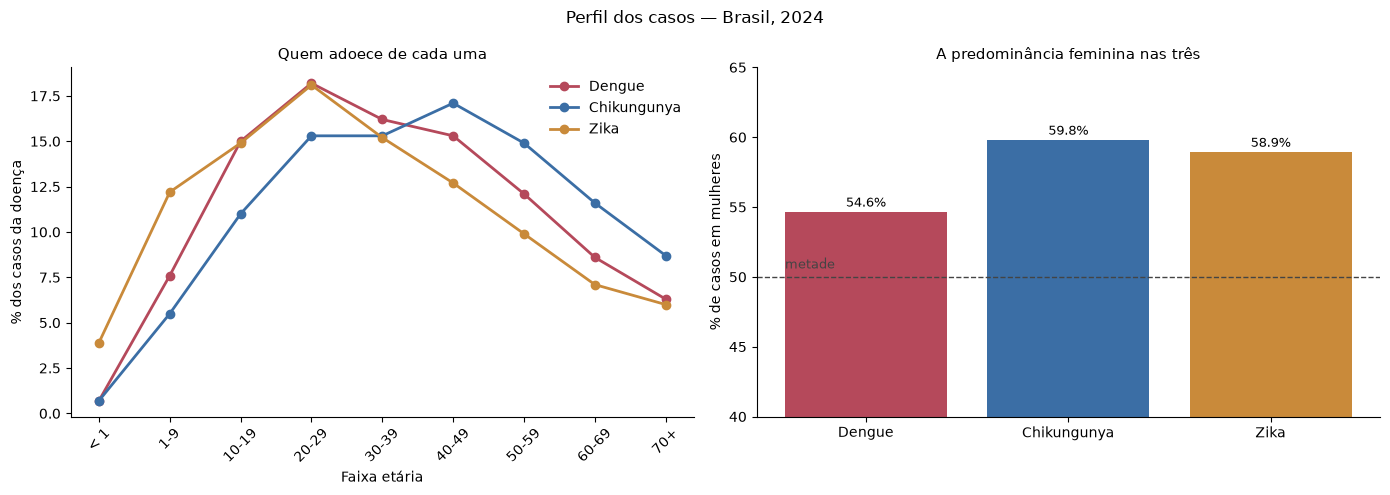

In [14]:
figura, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(14, 5))

for nome, cor in [("Dengue", "#b5495b"), ("Chikungunya", "#3b6ea5"),
                  ("Zika", "#c98a3a")]:
    if nome in resumo_idade:
        eixo1.plot(ORDEM, resumo_idade[nome], marker="o",
                   label=nome, color=cor, linewidth=2)

eixo1.set_ylabel("% dos casos da doença")
eixo1.set_xlabel("Faixa etária")
eixo1.set_title("Quem adoece de cada uma", fontsize=11)
eixo1.legend(frameon=False)
eixo1.tick_params(axis="x", rotation=45)

razao = []
for nome, dados in perfis.items():
    por_sexo = dados.groupby("sexo")["casos"].sum()
    if {"F", "M"}.issubset(por_sexo.index):
        razao.append((nome, por_sexo["F"] / (por_sexo["F"] + por_sexo["M"]) * 100))

nomes = [n for n, _ in razao]
eixo2.bar(nomes, [v for _, v in razao],
          color=[cores.get(n, "#9aa5b1") for n in nomes])
eixo2.axhline(50, color="#444", linestyle="--", linewidth=1)
eixo2.text(-0.4, 50.6, "metade", fontsize=9, color="#444")
eixo2.set_ylabel("% de casos em mulheres")
eixo2.set_ylim(40, 65)
eixo2.set_title("A predominância feminina nas três", fontsize=11)

for indice, (_, valor) in enumerate(razao):
    eixo2.text(indice, valor + 0.4, f"{valor:.1f}%", ha="center", fontsize=9)

for eixo in (eixo1, eixo2):
    eixo.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Perfil dos casos — Brasil, {ANO}", fontsize=12)
plt.tight_layout()
plt.show()

Duas leituras que vale registrar.

A **chikungunya adoece pessoas mais velhas** que a dengue. Isso é coerente com
o que se vê na clínica: a artralgia que persiste por meses atinge sobretudo
adultos de meia-idade e idosos, e é ela que leva ao serviço de saúde.

E as três predominam em **mulheres**. Parte é diferença real de exposição, mas
parte é o que a epidemiologia chama de viés de aferição: as mulheres procuram
mais o serviço de saúde e, por isso, são mais notificadas.

## 7. Gravidade e desfecho

O SINAN registra a classificação final e a evolução do caso. Cruzar as duas
mostra onde a dengue mata.

In [15]:
CLASSIFICACAO_DENGUE = {
    "10": "Dengue",
    "11": "Dengue com sinais de alarme",
    "12": "Dengue grave",
    "13": "Chikungunya",
    "8": "Descartado",
    "5": "Descartado",
}

caminho_dengue = arquivos["DENG"]
gravidade = con.execute(f"""
    SELECT CLASSI_FIN,
           count(*) AS casos,
           sum(CASE WHEN EVOLUCAO = '2' THEN 1 ELSE 0 END) AS obitos,
           sum(CASE WHEN HOSPITALIZ = '1' THEN 1 ELSE 0 END) AS internados
    FROM read_parquet('{caminho_dengue}')
    WHERE CLASSI_FIN IS NOT NULL
    GROUP BY 1 ORDER BY 2 DESC
""").df()

gravidade["classificação"] = [CLASSIFICACAO_DENGUE.get(c, f"código {c}")
                              for c in gravidade["CLASSI_FIN"]]
gravidade["Letalidade (%)"] = (gravidade["obitos"] / gravidade["casos"] * 100).round(2)
gravidade["Internação (%)"] = (gravidade["internados"] / gravidade["casos"] * 100).round(1)
gravidade = gravidade.set_index("classificação")[
    ["casos", "obitos", "Letalidade (%)", "internados", "Internação (%)"]]

print("Dengue por classificação final\n")
gravidade

Dengue por classificação final


,casos,obitos,Letalidade (%),internados,Internação (%)
classificação,,,,,
Dengue,5904136,1532.0,0.03,122377.0,2.1
Descartado,542641,3.0,0.00,8128.0,1.5
Dengue com sinais de alarme,101392,975.0,0.96,52658.0,51.9
Dengue grave,8831,3827.0,43.34,6939.0,78.6


A escada de letalidade é a razão de existir da classificação: dengue sem
gravidade mata pouquíssimo, com sinais de alarme mata mais, e a dengue grave
mata em proporção dezenas de vezes maior. É por isso que reconhecer os sinais
de alarme na porta de entrada salva vidas — o desfecho depende de identificar
a tempo em qual degrau o paciente está.

## 8. A vigilância chegou a tempo?

Entre sentir o primeiro sintoma e a notificação chegar ao sistema há um
intervalo. Ele mede a capacidade de resposta: uma epidemia detectada com três
semanas de atraso já se espalhou.

Mediana do intervalo entre sintoma e notificação: 3 dias
Notificados em até 2 dias: 49.9%
Notificados em até 7 dias: 91.2%


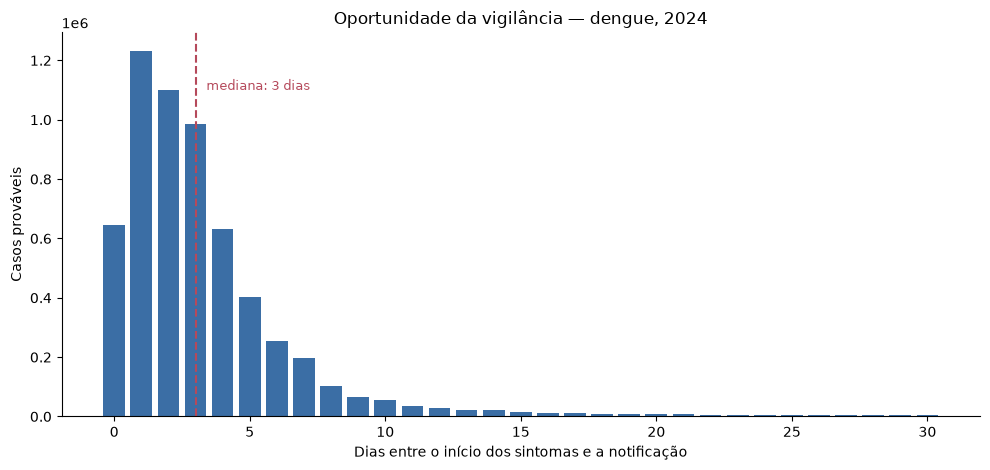

In [16]:
oportunidade = con.execute(f"""
    WITH base AS (
        SELECT date_diff('day', TRY_CAST(DT_SIN_PRI AS DATE),
                                TRY_CAST(DT_NOTIFIC AS DATE)) AS dias
        FROM read_parquet('{caminho_dengue}')
        WHERE {filtro_provavel("DENG")}
    )
    SELECT dias, count(*) AS casos
    FROM base
    WHERE dias BETWEEN 0 AND 60
    GROUP BY 1 ORDER BY 1
""").df()

total = oportunidade["casos"].sum()
acumulado = oportunidade["casos"].cumsum() / total * 100
ate_2 = acumulado[oportunidade["dias"] <= 2].max()
ate_7 = acumulado[oportunidade["dias"] <= 7].max()
mediana = oportunidade.loc[(acumulado >= 50).idxmax(), "dias"]

print(f"Mediana do intervalo entre sintoma e notificação: {mediana:.0f} dias")
print(f"Notificados em até 2 dias: {ate_2:.1f}%")
print(f"Notificados em até 7 dias: {ate_7:.1f}%")

figura, eixo = plt.subplots(figsize=(10, 4.8))
eixo.bar(oportunidade["dias"][:31], oportunidade["casos"][:31], color="#3b6ea5")
eixo.axvline(mediana, color="#b5495b", linestyle="--", linewidth=1.5)
eixo.text(mediana + 0.4, eixo.get_ylim()[1] * 0.85,
          f"mediana: {mediana:.0f} dias", color="#b5495b", fontsize=9)
eixo.set_xlabel("Dias entre o início dos sintomas e a notificação")
eixo.set_ylabel("Casos prováveis")
eixo.set_title(f"Oportunidade da vigilância — dengue, {ANO}", fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Conferindo com a realidade

In [17]:
dengue = painel.loc["Dengue"]
pico_dengue = curvas["Dengue"].idxmax()

print("Verificações de sanidade\n")
print(f"1. Casos prováveis de dengue no ano:  {mil(dengue['provaveis'])}")
print(f"2. Óbitos por dengue:                 {mil(dengue['obitos'])}")
print(f"3. Pico entre as semanas 8 e 20?      semana {pico_dengue} "
      f"({'sim' if 8 <= pico_dengue <= 20 else 'ATENÇÃO'})")
print(f"4. SP é o estado com mais casos?      "
      f"{'sim' if casos_por_uf('DENG').idxmax() == 'SP' else 'ATENÇÃO'}")
print()
print(f"Em {ANO}, o Ministério da Saúde registrou a maior epidemia de dengue da")
print("série histórica, com mais de 6 milhões de casos prováveis e cerca de")
print("6 mil óbitos confirmados. O verão de 2024 combinou El Niño, calor")
print("recorde e a circulação simultânea de vários sorotipos.")

Verificações de sanidade

1. Casos prováveis de dengue no ano:  6.022.283
2. Óbitos por dengue:                 6.337
3. Pico entre as semanas 8 e 20?      semana 12 (sim)


4. SP é o estado com mais casos?      sim

Em 2024, o Ministério da Saúde registrou a maior epidemia de dengue da
série histórica, com mais de 6 milhões de casos prováveis e cerca de
6 mil óbitos confirmados. O verão de 2024 combinou El Niño, calor
recorde e a circulação simultânea de vários sorotipos.


## 10. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro ano | `ANO = 2019` — mas confira no catálogo se existe |
| Só um estado | acrescente `WHERE SG_UF_NOT = '41'` nas consultas |
| Outra doença | `DOENCAS = {"LEPT": "Leptospirose"}` — são 49 agravos disponíveis |
| Municípios | agrupe por `ID_MN_RESI` em vez de `SG_UF_NOT` |
| Sintomas e comorbidades | as colunas `FEBRE`, `MIALGIA`, `DIABETES`, `HIPERTENSA` estão no arquivo |
| Sorotipo do vírus | coluna `SOROTIPO`, preenchida só nos casos com isolamento viral |
| Gestantes | `CS_GESTANT` — relevante sobretudo para zika |

### O que vale levar

O método: **consultar o arquivo com SQL em vez de carregá-lo**. É o que permite
analisar seis milhões e meio de notificações num Colab gratuito.
A definição de **caso provável** (notificações menos descartados) — é ela que
faz seus números baterem com o boletim do Ministério da Saúde. E, junto com
ela, a descoberta de que **o código do descarte muda de agravo para agravo**:
8 na dengue, 5 na chikungunya, 2 no zika. O jeito de identificá-lo sem a tabela
oficial é procurar o código em que ninguém morre.
A decodificação de `NU_IDADE_N`, que sem tratamento vira idade de mil anos.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: SINAN/DATASUS e IBGE, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*